# 04 — Sunum görselleri ve slayt notları

Bu notebook **sunum / rapor** için grafik üretir ve her bölümde **PowerPoint veya Google Slides’ta kullanabileceğin vurgulu cümleler** verir.

**Ön koşullar:** `02_preprocessing.ipynb` ve `03_modeling.ipynb` çalışmış olmalı; `data/processed/train_test_split.pkl` ve `models/model_registry.json` + kayıtlı model dosyaları mevcut olmalı.

**Çalışma dizini:** Jupyter’i proje kökünden veya `notebooks/` klasöründen açabilirsin; aşağıdaki kod her iki durumu da dener.

**İpucu:** Üretilen figürleri sağ tık → kaydet veya `plt.savefig(...)` satırlarını açarak PNG olarak diske yaz.

## Slayt akışı (özet)

| Slayt | İçerik | Bu notebook’ta |
|-------|--------|------------------|
| 1 | Başlık + problem | Metin (aşağıdaki öneri cümleler) |
| 2 | Veri ve churn oranı | Grafik 1 |
| 3 | Sözleşme / kategorik içgörü | Grafik 2 |
| 4 | Tenure ve ücret | Grafik 3 |
| 5 | İnternet hizmeti | Grafik 4 |
| 6 | Model karşılaştırması | Grafik 5 |
| 7 | Karmaşıklık matrisi + ROC | Grafik 6–7 |
| 8 | Özellik önemi | Grafik 8 |
| 9 | API / sistem | Ekran görüntüsü önerisi (metin) |

---

In [1]:
# Ortak: yollar, veri, model, test seti
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "processed").is_dir():
        return cwd
    if (cwd.parent / "data" / "processed").is_dir():
        return cwd.parent
    raise FileNotFoundError("data/processed bulunamadı. Jupyter kökünü proje klasörü yapın.")

ROOT = project_root()
PROC = ROOT / "data" / "processed" / "train_test_split.pkl"
DATA_XLS = ROOT / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.xls"
REG_PATH = ROOT / "models" / "model_registry.json"

bundle = joblib.load(PROC)
X_test = bundle["X_test"].copy()
y_test = bundle["y_test"]
feat_names = bundle["feature_columns"]
X_test = X_test.astype(np.float64)

registry = json.loads(REG_PATH.read_text(encoding="utf-8"))
best_key = registry["best_model_key"]
model_path = ROOT / "models" / registry["best_model_file"]
model = joblib.load(model_path)

df_raw = pd.read_csv(DATA_XLS)
df_raw = df_raw.drop(columns=["customerID"], errors="ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

print("Kök:", ROOT)
print("En iyi model:", best_key, "| Test:", X_test.shape)

Kök: C:\Users\Can\Desktop\data\churn-project-yzta
En iyi model: XGBoost | Test: (1409, 30)


---
## Slayt 2 — Hedef: Churn dağılımı

**Başlık önerisi:** *Müşteri kaybı veri seti dengesizdir*

### Sunumda vurgula (okunabilir cümleler)
> **“Veri setinde yaklaşık dört müşteriden biri churn; sınıflar dengesiz. Bu yüzden yalnızca doğruluk (accuracy) yetmez; recall ve F1 birlikte değerlendirilir.”**

> **“İş hedefi açısından gerçek churn’ü kaçırmak genelde yanlış alarma göre daha maliyetlidir; bu nedenle recall’a özellikle bakıyoruz.”**

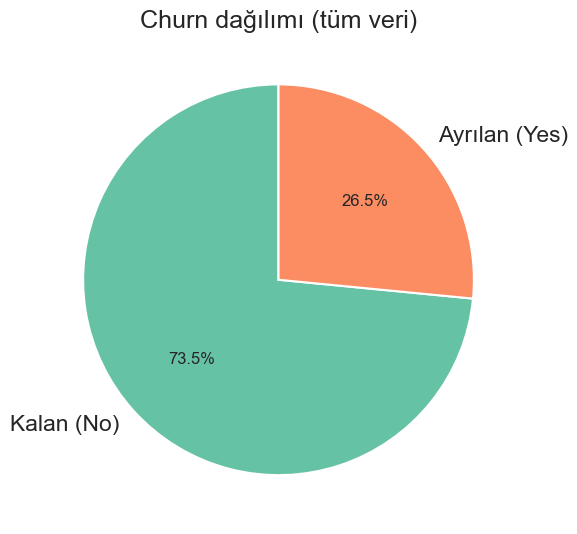

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))
churn_counts = df_raw["Churn"].value_counts()
colors = sns.color_palette("Set2", n_colors=2)
ax.pie(churn_counts, labels=["Kalan (No)", "Ayrılan (Yes)"], autopct="%1.1f%%", colors=colors, startangle=90)
ax.set_title("Churn dağılımı (tüm veri)")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_01_churn_pie.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Slayt 3 — Sözleşme tipi ve churn

**Başlık önerisi:** *Ay ay sözleşme churn riskini artırır*

### Sunumda vurgula
> **“Month-to-month sözleşmeli müşterilerde churn oranı, uzun dönem sözleşmelere göre belirgin şekilde yüksektir; bu EDA ile model sonuçlarında da öne çıkar.”**

> **“İş aksiyonu: uzun vadeli sözleşmeye teşvik veya erken uyarı kuralları bu segment için önceliklendirilebilir.”**

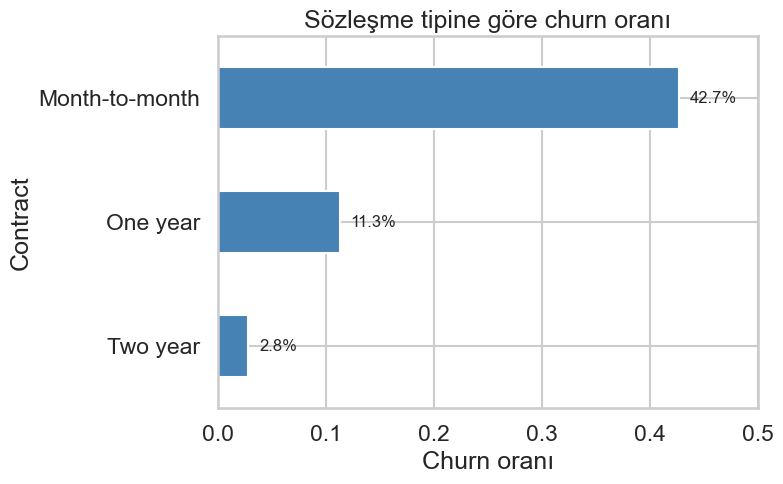

In [3]:
df = df_raw.copy()
df["Churn_bin"] = df["Churn"].map({"Yes": 1, "No": 0})
ct = df.groupby("Contract")["Churn_bin"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Churn oranı")
ax.set_title("Sözleşme tipine göre churn oranı")
ax.set_xlim(0, max(ct.max() * 1.15, 0.5))
for i, v in enumerate(ct):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_02_contract_churn.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Slayt 4 — Kıdem (tenure) ve aylık ücret

**Başlık önerisi:** *Yeni müşteriler ve ücret seviyesi churn ile ilişkili*

### Sunumda vurgula
> **“Düşük tenure — yani yeni müşteriler — churn açısından daha riskli bir gruptur.”**

> **“Yüksek aylık ücret ödeyen müşterilerde de churn eğilimi gözlenir; fiyatlandırma ve paket stratejisi bu grup için önemlidir.”**

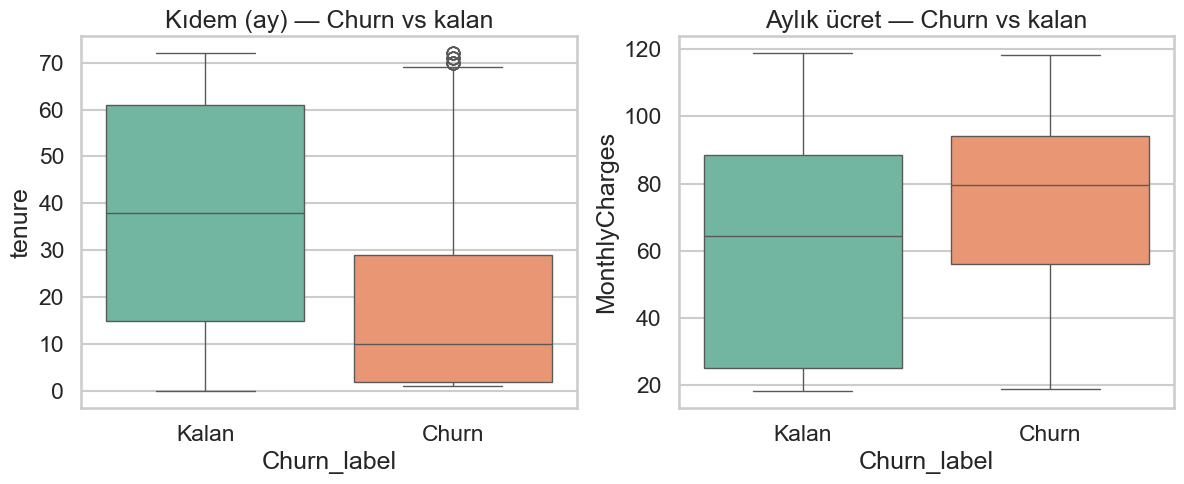

In [4]:
df = df_raw.copy()
df["Churn_label"] = df["Churn"].map({"Yes": "Churn", "No": "Kalan"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="Churn_label", y="tenure", ax=axes[0], hue="Churn_label", palette="Set2", legend=False)
axes[0].set_title("Kıdem (ay) — Churn vs kalan")
sns.boxplot(data=df, x="Churn_label", y="MonthlyCharges", ax=axes[1], hue="Churn_label", palette="Set2", legend=False)
axes[1].set_title("Aylık ücret — Churn vs kalan")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_03_tenure_charges.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Slayt 5 — İnternet hizmeti

**Başlık önerisi:** *Fiber optik segmentinde churn daha yüksek*

### Sunumda vurgula
> **“İnternet hizmeti tipine göre churn oranı değişiyor; özellikle fiber optik kullanıcılarında ayrılma oranı daha yüksektir.”**

> **“Bu tür segmentasyon, pazarlama ve müşteri başarısı ekipleri için hedef listesi oluşturmada kullanılabilir.”**

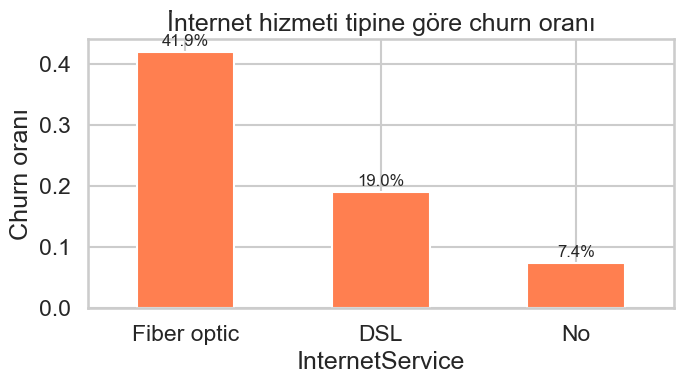

In [5]:
df = df_raw.copy()
df["Churn_bin"] = df["Churn"].map({"Yes": 1, "No": 0})
inet = df.groupby("InternetService")["Churn_bin"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
inet.plot(kind="bar", ax=ax, color="coral", rot=0)
ax.set_ylabel("Churn oranı")
ax.set_title("İnternet hizmeti tipine göre churn oranı")
for i, v in enumerate(inet):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_04_internet_churn.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Slayt 6 — Modellerin test performansı

**Başlık önerisi:** *Beş model karşılaştırıldı; seçim F1 ile yapıldı*

### Sunumda vurgula
> **“Logistic Regression’dan XGBoost ve LightGBM’e kadar beş farklı yaklaşım eğitildi; hepsi aynı test kümesinde, aynı ön işleme ile değerlendirildi.”**

> **“Dengesiz veride F1 skoru precision ve recall dengesini özetlediği için **test F1** ile en iyi model seçildi: registry’de kayıtlı model.”**

> **“Tabloda recall’a özellikle bakın: gerçek churn’ün ne kadarını yakaladığımızı gösterir.”**

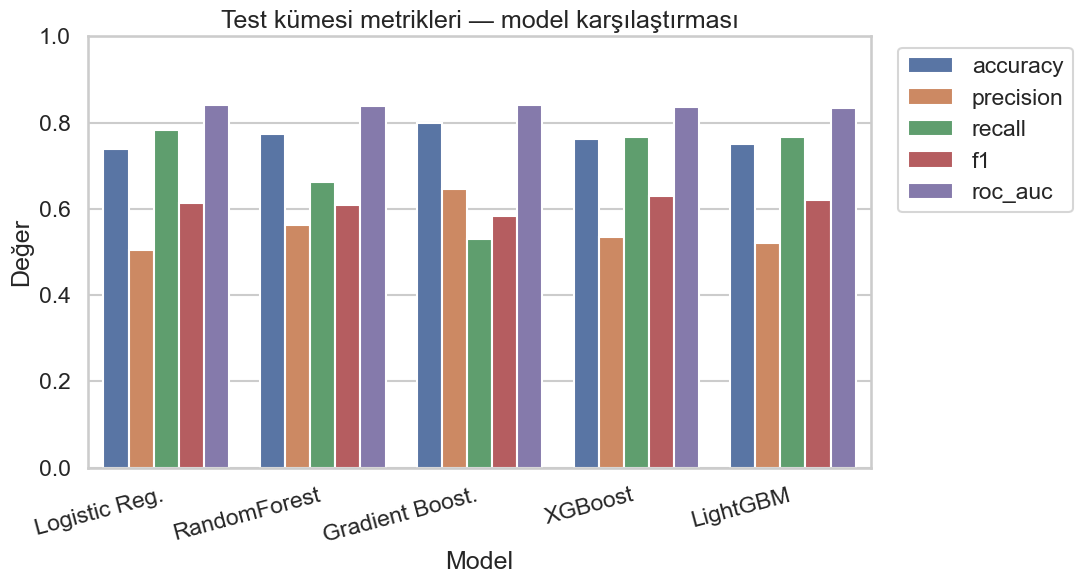

In [6]:
rows = []
for name, info in registry["models"].items():
    m = info["metrics_test"]
    rows.append({"Model": name.replace("Regression", " Reg.").replace("Boosting", " Boost."), **m})
met = pd.DataFrame(rows)
plot_df = met.melt(id_vars=["Model"], value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
 var_name="Metrik", value_name="Değer")

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_df, x="Model", y="Değer", hue="Metrik", ax=ax)
ax.set_title("Test kümesi metrikleri — model karşılaştırması")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_05_model_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Slayt 7 — En iyi model: hata analizi (karmaşıklık + ROC)

**Başlık önerisi:** *Seçilen modelin test performansı*

### Sunumda vurgula
> **“Karmaşıklık matrisi: kaç churn’ü doğru yakaladık, kaçını kaçırdık, ‘churn’ dediğimizde ne kadarı gerçekten churn?”**

> **“ROC eğrisi modelin sınıfları ayırma gücünü özetler; AUC tek sayıyla bu grafiğin özetidir.”**

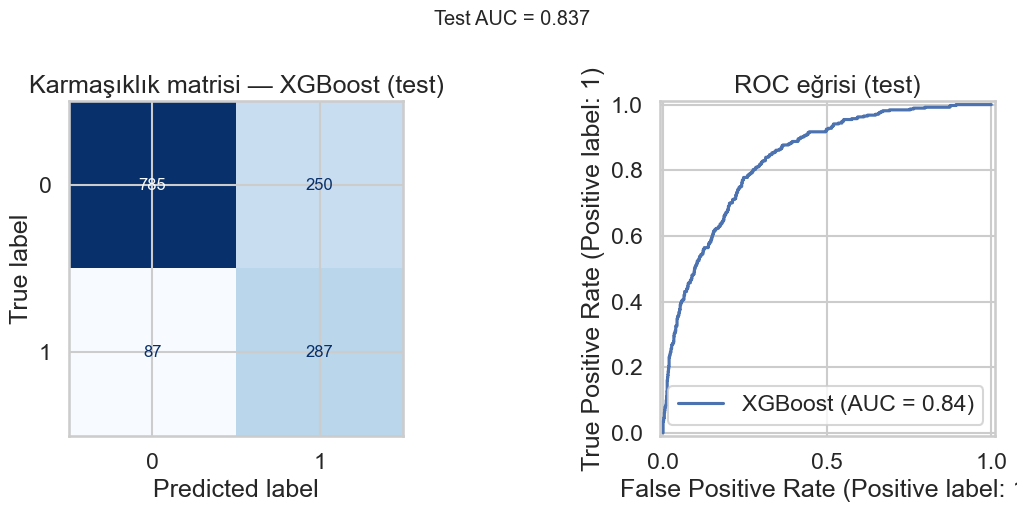

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Karmaşıklık matrisi — {best_key} (test)")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=best_key)
axes[1].set_title("ROC eğrisi (test)")
auc = roc_auc_score(y_test, y_proba)
fig.suptitle(f"Test AUC = {auc:.3f}", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_06_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Slayt 8 — Hangi özellikler önemli? (XGBoost feature importance)

**Başlık önerisi:** *Model hangi sinyallere ağırlık veriyor?*

### Sunumda vurgula
> **“Özellik önemi, modelin kararında hangi değişkenlere daha çok güvendiğini gösterir; iş yorumu için EDA bulgularıyla birlikte okunmalıdır.”**

> **“Buradaki sıra mutlak nedensellik değildir; ancak önceliklendirme ve açıklanabilirlik için faydalıdır.”**

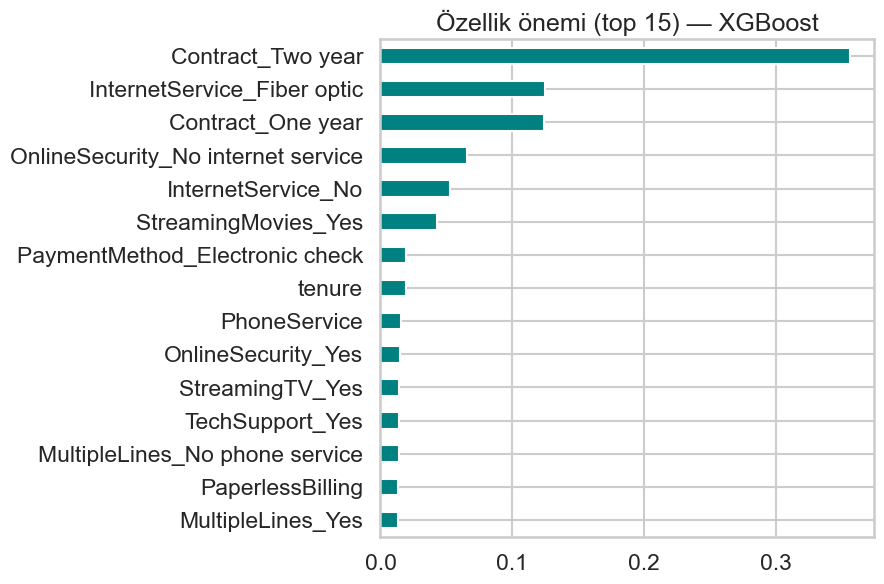

In [8]:
# XGBoost / tree modellerinde feature_importances_ yaygındır
if hasattr(model, "feature_importances_"):
    imp = pd.Series(model.feature_importances_, index=feat_names).sort_values(ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    imp.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Özellik önemi (top 15) — {best_key}")
    plt.tight_layout()
    plt.savefig(ROOT / "notebooks" / "fig_07_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Bu model feature_importances_ sağlamıyor; slayt için atlanabilir.")

---
## Slayt 9 — Sistem: API ve (isteğe bağlı) arayüz

**Başlık önerisi:** *Model üretimde: REST API*

### Sunumda vurgula
> **“Model sadece notebook’ta kalmıyor; FastAPI ile `/predict` ve ham müşteri için `/predict/raw` uçları sunuluyor.”**

> **“Streamlit formu veya Swagger (`/docs`) ekran görüntüsü, jüriye sistemin çalışır olduğunu hızlıca gösterir.”**

### Sen yapacaksın (grafik değil)
- `uvicorn api.app:app` çalışırken tarayıcıdan **http://localhost:8000/docs** ekran görüntüsü
- İsteğe bağlı: **Streamlit** tahmin ekranı görüntüsü

---

## Kapanış cümlesi önerisi

> **“Özetle: Telco churn verisinde dengesiz sınıf ve güçlü kategorik sinyaller var; çoklu model karşılaştırması ve F1 odaklı seçimle en iyi model belirlendi ve API ile servis haline getirildi.”**

---

*Notebook sonu — figürler `notebooks/fig_*.png` olarak kaydedildi (kod çalıştıysa).*